In [10]:
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
from methods import LimitCycleVectorField


adata = ad.read_h5ad("adata_wangle.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 3058 × 2000
    obs: 'Plate_Id', 'Condition_Id', 'Well_Id', 'RFP_log10_corrected', 'GFP_log10_corrected', 'Cell_cycle_possition', 'Cell_cycle_relativePos', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'circular_coords'
    var: 'gene_symbol', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'spliced_labeled', 'spliced_unlabeled', 'total_labeled', 'total_unlabeled', 'unspliced', 'unspliced_labeled', 'unspliced_unlabeled'
    obsp: 'connectivities', 'distances'


/Users/iwachsm/miniconda3/envs/cell-donut/lib/python3.14/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [11]:
# Extract attributes from adata
X_pca_data = adata.obsm["X_pca"]
theta_data = adata.obs['circular_coords'].values
X_umap_data = adata.obsm["X_umap"]

# Initialize solver
d_dimensions = X_pca_data.shape[1]
model = LimitCycleVectorField(d_space=d_dimensions, hidden_dim=64)

print("Fitting step 1: Smooth Neural Network Limit Cycle (Gamma)...")
model.fit_gamma(theta_data, X_pca_data, epochs=500, lr=2e-3, smooth_penalty=0.5)

print("Fitting step 2: Periodic 1D Density Estimator...")
model.fit_density(theta_data)

print("Fitting step 4: Training Smooth Space-to-Circle Coordinate MLP...")
model.fit_coordinate_net(X_pca_data, theta_data, epochs=500, lr=1e-3)

print("Fitting Visualization Helper: PCA-to-UMAP Coordinator Regressor...")
model.fit_umap_projector(X_pca_data, X_umap_data)

print("\nPipeline successfully trained! The entire field is now globally smooth and differentiable.")

Fitting step 1: Smooth Neural Network Limit Cycle (Gamma)...
Epoch: 0
Epoch: 100
Epoch: 200
Epoch: 300
Epoch: 400
Fitting step 2: Periodic 1D Density Estimator...
Fitting step 4: Training Smooth Space-to-Circle Coordinate MLP...
Fitting Visualization Helper: PCA-to-UMAP Coordinator Regressor...

Pipeline successfully trained! The entire field is now globally smooth and differentiable.


In [ ]:
# Compute velocities for all observations in our PCA dataset
# Tune hyperparameters: C scaling overall speed, lmbda governing centripetal pull strength
velocities_pca = model.compute_velocity(X_pca_data, C=0.2, lmbda=0.1)

# Project high-dimensional velocity vectors into the UMAP coordinates
X_umap_coords, velocities_umap = model.project_velocity_to_umap(X_pca_data, velocities_pca)


start_points_pca = [
    X_pca_data[i] for i in range(10)
]

trajectories_pca = []
trajectories_umap = []

for p0 in start_points_pca:
    traj_pca = model.simulate_trajectory(p0, steps=10000, dt=0.001, C=0.2, lmbda=0.1)
    traj_umap = model.pca_to_umap.predict(traj_pca)
    trajectories_pca.append(traj_pca)
    trajectories_umap.append(traj_umap)

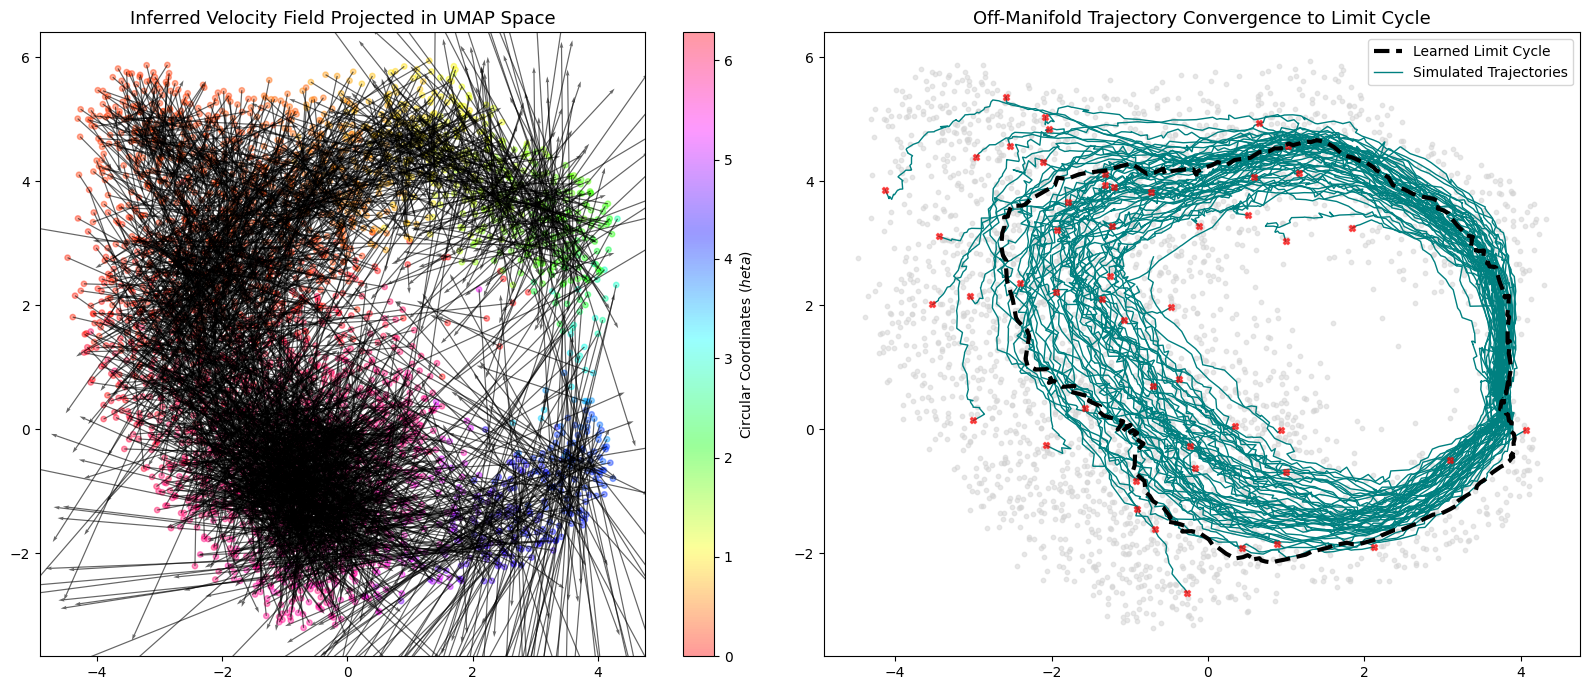

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Vector Field ---
scatter1 = ax[0].scatter(X_umap_data[:, 0], X_umap_data[:, 1], c=theta_data, cmap='hsv', s=15, alpha=0.4)
ax[0].quiver(X_umap_coords[:, 0], X_umap_coords[:, 1], 
             velocities_umap[:, 0], velocities_umap[:, 1], 
             color='black', alpha=0.6, scale=15, width=0.002)
ax[0].set_title("Inferred Velocity Field Projected in UMAP Space", fontsize=13)
fig.colorbar(scatter1, ax=ax[0], label='Circular Coordinates ($\theta$)')

# --- Plot 2: Trajectories and Limit Cycle ---
# Background data points
ax[1].scatter(X_umap_data[:, 0], X_umap_data[:, 1], color='lightgray', s=10, alpha=0.5)

# Generate and plot the learned analytic limit cycle (gamma)
theta_grid = np.linspace(0, 2*np.pi, 1000)
gamma_pca, _ = model._get_gamma_and_tangent(theta_grid)
gamma_umap = model.pca_to_umap.predict(gamma_pca)
ax[1].plot(gamma_umap[:, 0], gamma_umap[:, 1], color='black', linestyle='--', linewidth=3, zorder=10, label='Learned Limit Cycle')

# Plot the 100 simulated trajectories
for idx, traj in enumerate(trajectories_umap):
    # Only add the label to the legend once
    lbl = 'Simulated Trajectories' if idx == 0 else None
    
    # Use a thinner line and high transparency (alpha=0.3) so dense areas overlap beautifully
    ax[1].plot(traj[:, 0], traj[:, 1], color='teal', alpha=1, linewidth=1.0, label=lbl)
    
    # Make the start markers smaller (s=20) and slightly transparent
    ax[1].scatter(traj[0, 0], traj[0, 1], color='red', marker='X', s=20, zorder=5, alpha=0.6)

ax[1].set_title("Off-Manifold Trajectory Convergence to Limit Cycle", fontsize=13)
ax[1].legend()

plt.tight_layout()
plt.show()